<a href="https://colab.research.google.com/github/brittanybee-alt/Supervised-Learning/blob/main/Case_Study_RR_Diner_Coffee_%5BBrittany_Barrion%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Sourcing and loading
1a. Import Packages

In [83]:
import pandas as pd
import numpy as np
from sklearn import tree, metrics
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
from io import StringIO
from IPython.display import Image
import pydotplus

1b. Load data

In [84]:
coffeeData = pd.read_csv('/content/RRDinerCoffeeData.csv')

1c. Explore the data

In [85]:
coffeeData.head(8)

,Age,Gender,num_coffeeBags_per_year,spent_week,spent_month,SlrAY,Distance,Online,Decision
0,36,Female,0,24,73,42789,0.003168,0,1.0
1,24,Male,0,44,164,74035,0.520906,0,NaN
2,24,Male,0,39,119,30563,0.916005,1,1.0
3,20,Male,0,30,107,13166,0.932098,1,NaN
4,24,Female,0,20,36,14244,0.965881,0,1.0
5,20,female,0,23,28,14293,1.036346,1,1.0
6,34,Female,0,55,202,91035,1.134851,0,1.0
7,24,Female,0,20,34,17425,1.193188,0,NaN


In [86]:
coffeeData.shape

(702, 9)

In [87]:
coffeeData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 702 entries, 0 to 701
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      702 non-null    int64  
 1   Gender                   702 non-null    object 
 2   num_coffeeBags_per_year  702 non-null    int64  
 3   spent_week               702 non-null    int64  
 4   spent_month              702 non-null    int64  
 5   SlrAY                    702 non-null    int64  
 6   Distance                 702 non-null    float64
 7   Online                   702 non-null    int64  
 8   Decision                 474 non-null    float64
dtypes: float64(2), int64(6), object(1)
memory usage: 49.5+ KB


In [88]:
coffeeData.describe(include = 'all')

,Age,Gender,num_coffeeBags_per_year,spent_week,spent_month,SlrAY,Distance,Online,Decision
count,702.000000,702,702.000000,702.000000,702.000000,702.000000,702.000000,702.000000,474.000000
unique,NaN,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,355,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,34.243590,NaN,2.710826,32.853276,107.923077,43819.843305,4.559186,0.531339,0.639241
std,13.927945,NaN,1.593629,15.731878,55.348485,26192.626943,3.116275,0.499373,0.480728
min,16.000000,NaN,0.000000,0.000000,0.000000,1617.000000,0.003168,0.000000,0.000000
25%,23.000000,NaN,1.000000,24.250000,62.000000,22812.250000,1.877812,0.000000,0.000000
50%,28.000000,NaN,3.000000,36.000000,113.500000,41975.000000,4.196167,1.000000,1.000000
75%,46.000000,NaN,4.000000,43.000000,150.750000,60223.000000,6.712022,1.000000,1.000000


2. Cleaning, transforming and visualizing
2a. Cleaning the data

In [89]:
coffeeData.columns

Index(['Age', 'Gender', 'num_coffeeBags_per_year', 'spent_week', 'spent_month',
       'SlrAY', 'Distance', 'Online', 'Decision'],
      dtype='object')

In [90]:
coffeeData.rename(columns = {'spent_month':'spent_last_month', 'spent_week':'spent_last_week', 'SlrAY':'Salary'}, inplace = True)

In [91]:
coffeeData.columns

Index(['Age', 'Gender', 'num_coffeeBags_per_year', 'spent_last_week',
       'spent_last_month', 'Salary', 'Distance', 'Online', 'Decision'],
      dtype='object')

In [92]:
coffeeData['Gender'].describe()

,Gender
count,702
unique,9
top,Male
freq,355


In [93]:
coffeeData['Gender'].unique()

array(['Female', 'Male', 'female', 'F', 'f ', 'FEMALE', 'MALE', 'male',
       'M'], dtype=object)

In [94]:
coffeeData['Gender'] = coffeeData['Gender'].replace(['female', 'F', 'f ', 'FEMALE'], "Female")

In [95]:
coffeeData['Gender'].unique()

array(['Female', 'Male', 'MALE', 'male', 'M'], dtype=object)

In [96]:
coffeeData['Gender'] = coffeeData['Gender'].replace(['MALE', 'male', 'M'], 'Male')

In [97]:
coffeeData['Gender'].unique()

array(['Female', 'Male'], dtype=object)

In [98]:
coffeeData['Decision'].unique()

array([ 1., nan,  0.])

In [99]:
coffeeData['Decision'] = coffeeData['Decision'].replace(1., 'YES')
coffeeData['Decision'] = coffeeData['Decision'].replace(0., 'NO')
coffeeData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 702 entries, 0 to 701
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      702 non-null    int64  
 1   Gender                   702 non-null    object 
 2   num_coffeeBags_per_year  702 non-null    int64  
 3   spent_last_week          702 non-null    int64  
 4   spent_last_month         702 non-null    int64  
 5   Salary                   702 non-null    int64  
 6   Distance                 702 non-null    float64
 7   Online                   702 non-null    int64  
 8   Decision                 474 non-null    object 
dtypes: float64(1), int64(6), object(2)
memory usage: 49.5+ KB


In [100]:
coffeeData['Decision'].unique()

array(['YES', nan, 'NO'], dtype=object)

2b. Train/test split

In [101]:
NOPrediction = coffeeData.dropna()
NOPrediction['Decision'].describe()

,Decision
count,474
unique,2
top,YES
freq,303


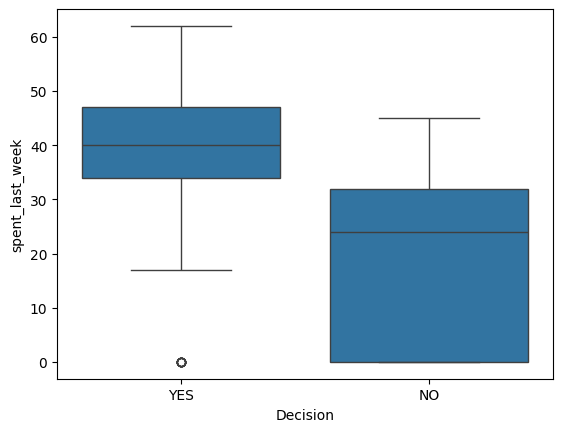

In [102]:
sns.boxplot(y='spent_last_week', x='Decision', data=NOPrediction)
plt.show()

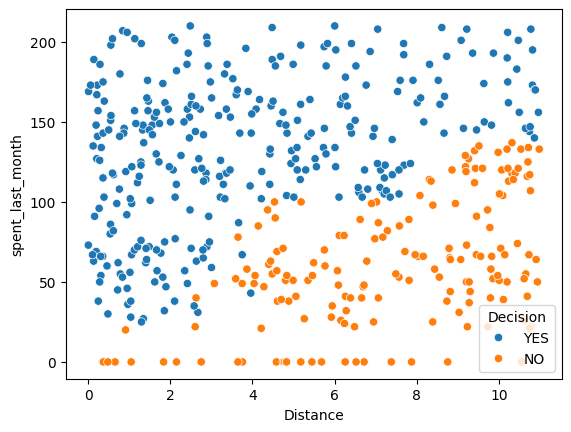

In [103]:
sns.scatterplot(y='spent_last_month', x='Distance', hue='Decision', data=NOPrediction)
plt.show()

Can you admissibly conclude anything from this scatterplot? Remember: we are trying to build a tree to classify unseen examples. Write your answer here:

Yes, but only certain kinds of conclusions are admissible. Since the goal is a decision tree, which makes axis-aligned splits on one feature at a time, the plot tells you which splits look promising. It can’t give you exact thresholds or tell you how well the tree will generalize.

In [104]:
Prediction = coffeeData[pd.isnull(coffeeData['Decision'])]
Prediction.head()

,Age,Gender,num_coffeeBags_per_year,spent_last_week,spent_last_month,Salary,Distance,Online,Decision
1,24,Male,0,44,164,74035,0.520906,0,NaN
3,20,Male,0,30,107,13166,0.932098,1,NaN
7,24,Female,0,20,34,17425,1.193188,0,NaN
11,24,Female,0,40,153,84803,1.655096,1,NaN
12,21,Female,0,38,122,42338,1.714179,1,NaN


In [105]:
Prediction.describe()

,Age,num_coffeeBags_per_year,spent_last_week,spent_last_month,Salary,Distance,Online
count,228.000000,228.000000,228.000000,228.000000,228.000000,228.000000,228.000000
mean,31.802632,2.960526,33.394737,110.407895,41923.741228,3.428836,0.570175
std,14.302293,1.585514,15.697930,53.786536,27406.768360,2.153102,0.496140
min,16.000000,0.000000,0.000000,0.000000,1617.000000,0.010048,0.000000
25%,22.000000,2.000000,25.750000,65.000000,15911.500000,1.699408,0.000000
50%,25.000000,3.000000,37.000000,113.500000,40987.500000,3.208673,1.000000
75%,39.000000,4.000000,44.000000,151.250000,58537.000000,5.261184,1.000000
max,67.000000,5.000000,62.000000,210.000000,182058.000000,10.871566,1.000000


In [106]:
NOPrediction.columns

Index(['Age', 'Gender', 'num_coffeeBags_per_year', 'spent_last_week',
       'spent_last_month', 'Salary', 'Distance', 'Online', 'Decision'],
      dtype='object')

In [107]:
features = ['Age', 'Gender', 'num_coffeeBags_per_year', 'spent_last_week', 'spent_last_month', 'Salary', 'Distance', 'Online']

X = NOPrediction[features]
y = NOPrediction.Decision

In [108]:
X = pd.get_dummies(X)

In [109]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=246)

3. Modelling

Model 1: Entropy model - no max_depth

In [110]:
entr_model = tree.DecisionTreeClassifier(criterion='entropy', random_state=1234)
entr_model.fit(X_train, y_train)
y_pred = entr_model.predict(X_test)
y_pred = pd.Series(y_pred)

entr_model

DecisionTreeClassifier(criterion='entropy', random_state=1234)

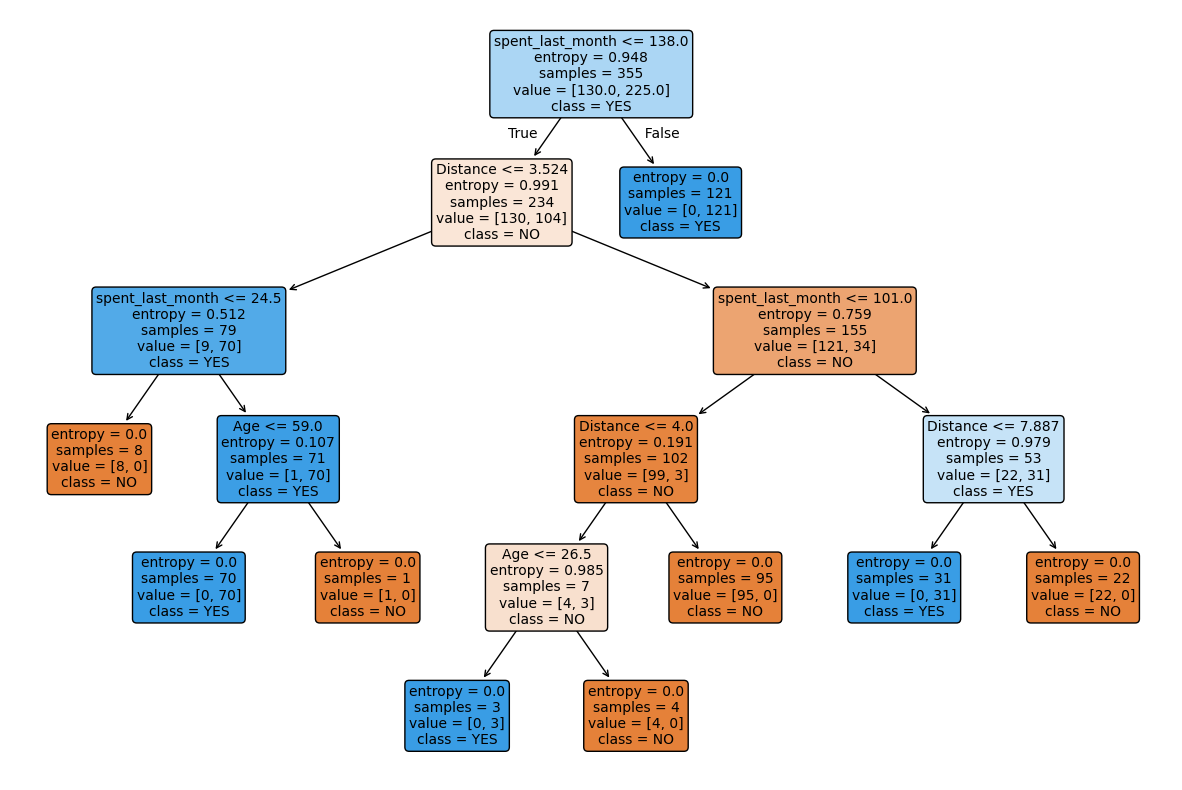

In [111]:
plt.figure(figsize=(15, 10))
tree.plot_tree(entr_model,
               feature_names=list(X_train.columns),
               class_names=['NO', 'YES'],
               filled=True,
               rounded=True,
               fontsize=10)
plt.show()

Model 1: Entropy model - no max_depth: Interpretation and evaluation

In [112]:
print("Model Entropy - no max depth")
print("Accuracy:", metrics.accuracy_score(y_test,y_pred))
print("Balanced accuracy:", metrics.balanced_accuracy_score(y_test,y_pred))
print('Precision score for "Yes"' , metrics.precision_score(y_test,y_pred, pos_label = "YES"))
print('Precision score for "No"' , metrics.precision_score(y_test,y_pred, pos_label = "NO"))
print('Recall score for "Yes"' , metrics.recall_score(y_test,y_pred, pos_label = "YES"))
print('Recall score for "No"' , metrics.recall_score(y_test,y_pred, pos_label = "NO"))

Model Entropy - no max depth
Accuracy: 0.9915966386554622
Balanced accuracy: 0.9878048780487805
Precision score for "Yes" 0.9873417721518988
Precision score for "No" 1.0
Recall score for "Yes" 1.0
Recall score for "No" 0.975609756097561


What can you infer from these results? Write your conclusions here:

The model looks excellent, but it’s an unpruned tree, so treat the numbers with some skepticism.

Performance: Accuracy of 99.2% (118 of 119 correct, assuming these are test-set numbers) against a majority-class baseline of about 65%. The one error is a NO predicted as YES, which explains recall for NO of 0.976 and precision for YES of 0.987.
What drives it: spent_last_month and Distance do the real work, and their thresholds (138 and about 3.5) match the scatterplot. Age appears only in tiny, deep splits, so it’s likely memorized noise.
Caveats: With no max depth, training accuracy is 100%, so check the train/test gap. A test set of 119 is small, and a single error moves accuracy by about 0.8 points.

Model 2: Gini impurity model - no max depth

In [113]:
gini_model = tree.DecisionTreeClassifier(criterion='gini', random_state=1234)

gini_model.fit(X_train, y_train)
y_pred = gini_model.predict(X_test)
y_pred = pd.Series(y_pred)

gini_model

DecisionTreeClassifier(random_state=1234)

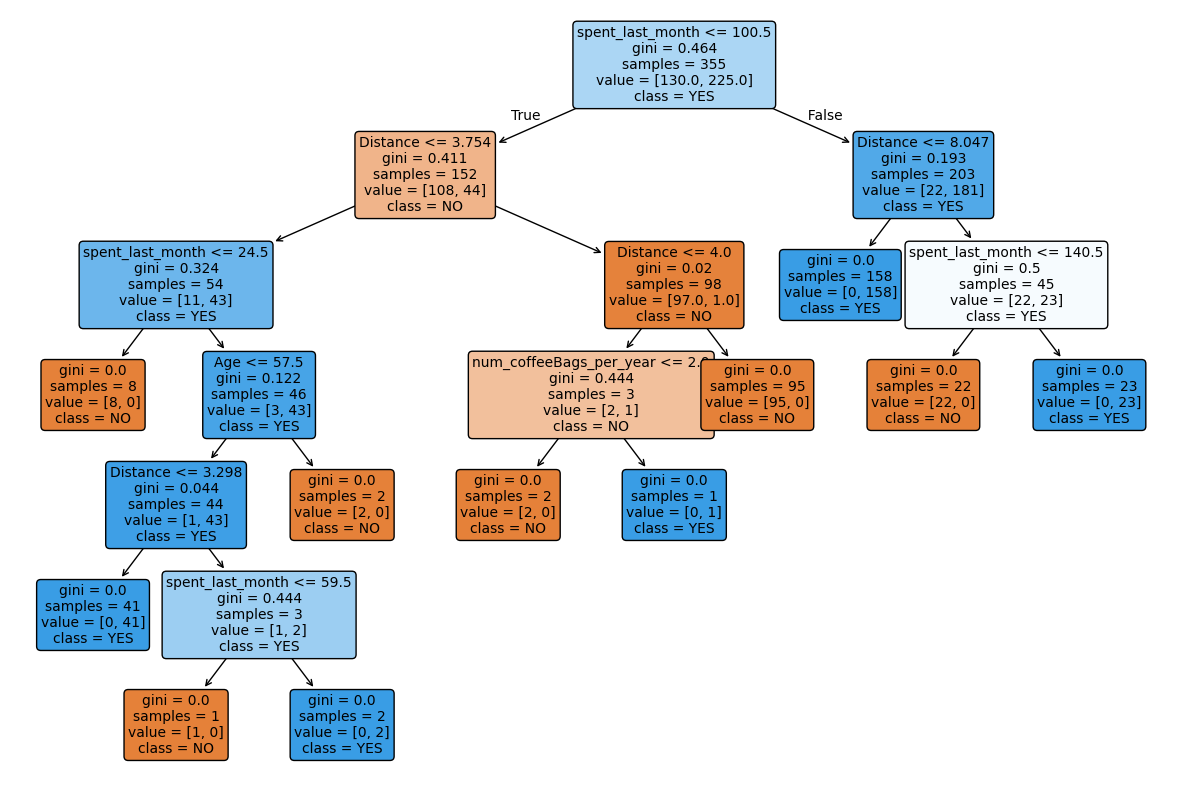

In [114]:
plt.figure(figsize=(15, 10))
tree.plot_tree(gini_model,
               feature_names=list(X_train.columns),
               class_names=['NO', 'YES'],
               filled=True,
               rounded=True,
               fontsize=10)
plt.show()

In [115]:
print("Model Gini impurity model")
print("Accuracy:", metrics.accuracy_score(y_test,y_pred))
print("Balanced accuracy:", metrics.balanced_accuracy_score(y_test,y_pred))
print('Precision score' , metrics.precision_score(y_test,y_pred, pos_label = "YES"))
print('Recall score' , metrics.recall_score(y_test,y_pred, pos_label = "NO"))

Model Gini impurity model
Accuracy: 0.9831932773109243
Balanced accuracy: 0.9813946216385241
Precision score 0.9871794871794872
Recall score 0.975609756097561


How do the results here compare to the previous model? Write your judgements here:

The two models perform essentially the same. Entropy is ahead by a single test example, which is well within noise.

The metrics fit two errors. Your balanced accuracy only works out if one NO was predicted YES (recall 40/41 = 0.976) and one YES was predicted NO (77/78 = 0.987). The unlabeled “Precision” and “Recall” lines seem to be for different classes, so label them in your code.
Both trees find the same structure. They split on spending near 100 and 138-140, and on Distance near 3.5-4 and 8, which match the scatterplot. Both approximate the diagonal boundary with a staircase.
The Gini tree uses more noise. It splits on Age twice and on num_coffeeBags_per_year, and those splits isolate 1-3 samples. The entropy tree uses Age only in its deepest splits.

Model 3: Entropy model - max depth  3

In [121]:
entr_model2 = tree.DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=1234)
entr_model2.fit(X_train, y_train)
y_pred = entr_model2.predict(X_test)
y_pred = pd.Series(y_pred)

entr_model2

DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=1234)

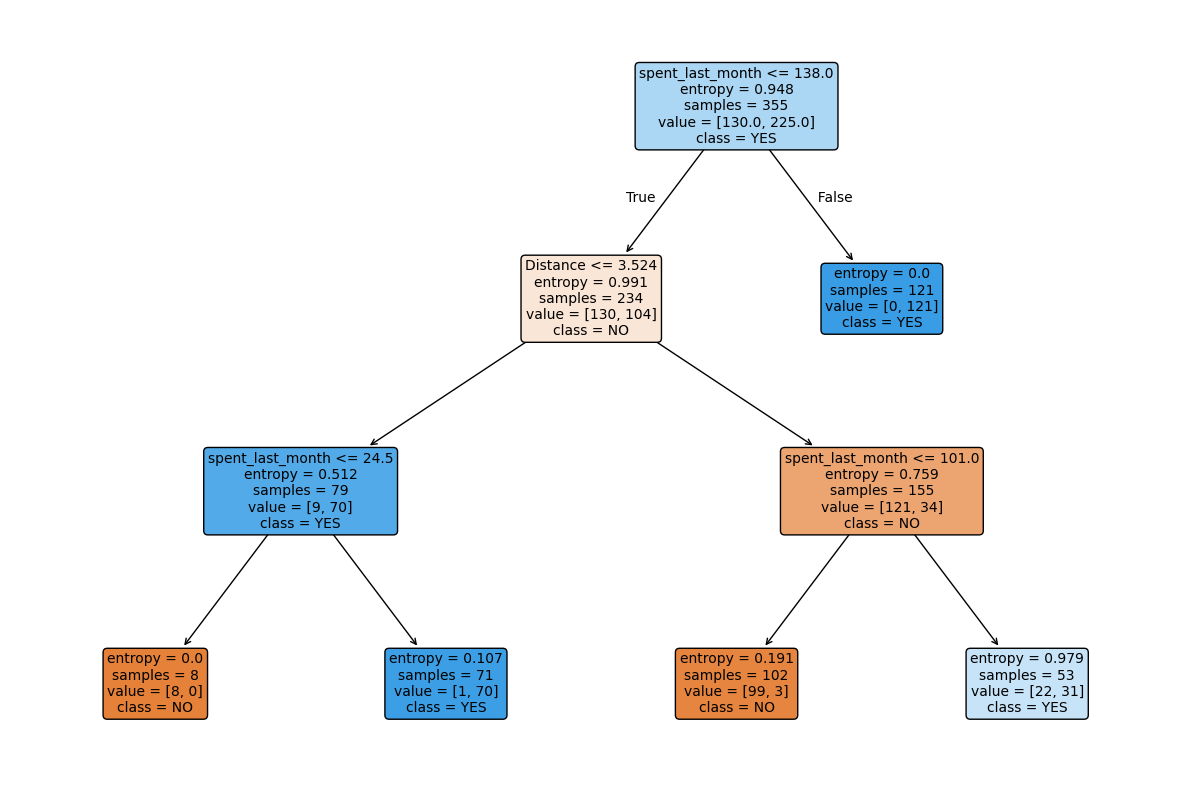

In [119]:
plt.figure(figsize=(15, 10))
tree.plot_tree(entr_model2,
               feature_names=list(X_train.columns),
               class_names=['NO', 'YES'],
               filled=True,
               rounded=True,
               fontsize=10)
plt.show()

In [122]:
print("Model Entropy model max depth 3")
print("Accuracy:", metrics.accuracy_score(y_test,y_pred))
print("Balanced accuracy:", metrics.balanced_accuracy_score(y_test,y_pred))
print('Precision score for "Yes"' , metrics.precision_score(y_test,y_pred, pos_label = "YES"))
print('Recall score for "No"' , metrics.recall_score(y_test,y_pred, pos_label = "NO"))

Model Entropy model max depth 3
Accuracy: 0.907563025210084
Balanced accuracy: 0.8658536585365854
Precision score for "Yes" 0.8764044943820225
Recall score for "No" 0.7317073170731707


So our accuracy decreased, but is this certainly an inferior tree to the max depth original tree we did with Model 1? Write your conclusions here:

Depth 3 is too shallow. Accuracy drops from about 99% to 91% because it never makes the Distance split near 8.

All 11 errors are NO predicted as YES. Recall for YES is 1.0, but recall for NO is only 0.73 (30/41), so balanced accuracy (0.866) falls well below accuracy.
One leaf causes it. The right-hand leaf (spend 101-138, Distance > 3.5) holds 22 NO and 31 YES but is labeled YES. The deeper trees separated these with a Distance split near 8.
The best model is probably in between. Keep that Distance split, but drop the noisy Age splits.

Model 4: Gini impurity model - max depth 3

In [123]:
gini_model2 = tree.DecisionTreeClassifier(criterion='gini', random_state=1234, max_depth=3)

gini_model2.fit(X_train, y_train)
y_pred = gini_model2.predict(X_test)
y_pred = pd.Series(y_pred)

gini_model2

DecisionTreeClassifier(max_depth=3, random_state=1234)

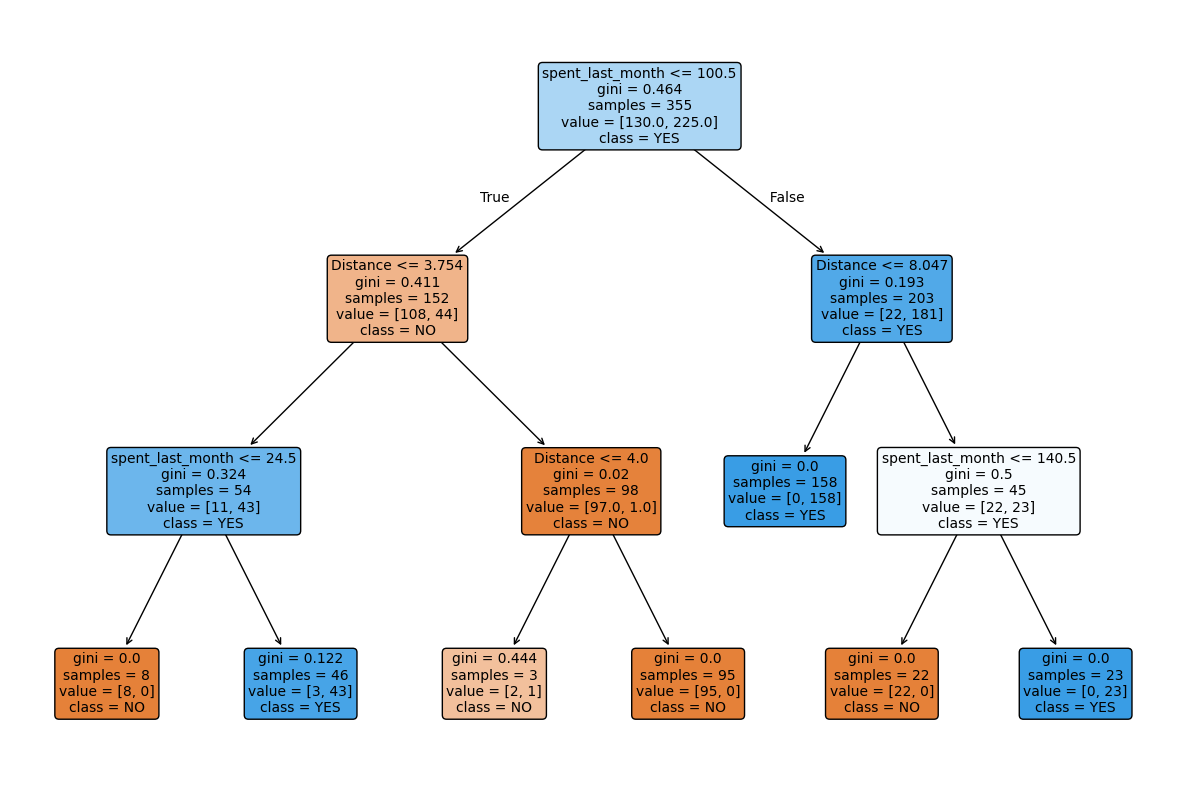

In [124]:
plt.figure(figsize=(15, 10))
tree.plot_tree(gini_model2,
               feature_names=list(X_train.columns),
               class_names=['NO', 'YES'],
               filled=True,
               rounded=True,
               fontsize=10)
plt.show()

In [125]:
print("Gini impurity  model - max depth 3")
print("Accuracy:", metrics.accuracy_score(y_test,y_pred))
print("Balanced accuracy:", metrics.balanced_accuracy_score(y_test,y_pred))
print('Precision score' , metrics.precision_score(y_test,y_pred, pos_label = "YES"))
print('Recall score' , metrics.recall_score(y_test,y_pred, pos_label = "NO"))

Gini impurity  model - max depth 3
Accuracy: 0.9747899159663865
Balanced accuracy: 0.9691994996873046
Precision score 0.9746835443037974
Recall score 0.9512195121951219


Now this is an elegant tree. Its accuracy might not be the highest, but it's still the best model we've produced so far. Why is that? Write your answer here:

It’s the best model because it gets nearly the same accuracy with far less complexity, which makes it the one most likely to hold up on unseen data.

4. Evaluating and concluding

4a. How many customers will buy Hidden Farm coffee?

In [126]:
coffeeData['Decision'].value_counts()

,count
Decision,
YES,303
NO,171


In [127]:
new_X = ['Age', 'Gender', 'num_coffeeBags_per_year', 'spent_last_week', 'spent_last_month', 'Salary', 'Distance', 'Online']

new_X = Prediction[new_X]

In [128]:
new_X = pd.get_dummies(new_X)

potential_buyers = gini_model2.predict(new_X)

In [129]:
np.unique(potential_buyers, return_counts=True)

(array(['NO', 'YES'], dtype=object), array([ 45, 183]))

The total number of potential buyers is 303 + 183 = 486

In [130]:
print("The total number of surveyed people was", coffeeData.Salary.count())

The total number of surveyed people was 702


In [131]:
486/702

0.6923076923076923

In [132]:
print("Only ", round((486/702)*100, 2), "% of people want to buy the Hidden Farm coffee." )

Only  69.23 % of people want to buy the Hidden Farm coffee.


4b. Decision

5. Random Forest

5a. Import necessary modules

In [133]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification

5b. Model

In [134]:
firstRFModel = RandomForestClassifier(max_depth=3, random_state=1234)
firstRFModel.fit(X_train, y_train)

RandomForestClassifier(max_depth=3, random_state=1234)

In [137]:
y_pred = firstRFModel.predict(X_test)
y_pred = pd.Series(y_pred)

firstRFModel

RandomForestClassifier(max_depth=3, random_state=1234)

5c. Revise conclusion

Has your conclusion changed? Or is the result of executing random forest the same as your best model reached by a single decision tree?

No my conclusion has not changed